In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

clients =pd.read_csv("clients.csv")
properties =pd.read_csv("properties.csv")


In [77]:
print("clients:", clients.shape)
print("properties:" ,properties.shape)

clients: (2000, 12)
properties: (10000, 9)


In [78]:
clients.head()


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [79]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [80]:
clients.describe()


,satisfaction_score
count,2000.000000
mean,3.029000
std,1.413562
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [81]:
properties.describe()


,listing_id,tower_number,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,105898.277400,10.370100,28.99920,1139.941412
std,74414.566199,5.769025,16.88242,418.373967
min,1002.000000,1.000000,1.00000,410.710000
25%,50389.750000,5.000000,15.00000,782.200000
50%,100404.500000,10.000000,29.00000,1110.880000
75%,150411.250000,15.000000,43.00000,1499.000000
max,990026.000000,20.000000,70.00000,1957.160000


In [82]:
clients.info()
properties.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 312.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -

In [83]:
clients.duplicated().sum()


np.int64(0)

In [84]:
properties.duplicated().sum()

np.int64(0)

In [85]:
clients.isnull().sum()


client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [86]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [87]:
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [88]:
properties["sale_price"].describe()

count     10000.000000
mean     344374.678683
std      131563.099417
min       97402.800000
25%      232173.642500
50%      330680.845000
75%      448852.575000
max      736652.270000
Name: sale_price, dtype: float64

In [89]:
clients['date_of_birth'].isna().sum()

np.int64(0)

In [90]:
clients["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"],
errors='coerce')

reference_date = pd.Timestamp.today()

clients["age"] = (
    (reference_date - clients["date_of_birth"]).dt.days / 365.25
).round().astype('Int64')

In [91]:
properties["client_ref"].isin(clients["client_id"]).sum()

np.int64(7305)

In [92]:
properties["client_ref"].nunique()

2000

In [93]:
clients["client_id"].nunique()

2000

In [94]:
property_summary = properties.groupby("client_ref").agg(
    total_properties=("listing_id", "count"),
    total_investment=("sale_price", "sum"),
    average_property_value=("sale_price", "mean"),
    average_property_size=("floor_area_sqft", "mean")
).reset_index()

In [95]:
property_summary.head()

,client_ref,total_properties,total_investment,average_property_value,average_property_size
0,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,13,3653385.38,281029.644615,927.296154


In [96]:
buyer_data = clients.merge(
    property_summary,
    left_on="client_id",
    right_on="client_ref",
    how="left"
)

In [97]:
buyer_data.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,client_ref,total_properties,total_investment,average_property_value,average_property_size
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,Trystan,Oconnor,NaT,M,USA,California,Home,1,No,Website,<NA>,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,Kale,Gay,1959-04-07,M,USA,California,Home,4,Yes,Agency,67,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,Russell,Gross,NaT,M,USA,California,Home,5,No,Website,<NA>,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,Company,Marleez,Co,NaT,M,USA,California,Investment,5,No,Website,<NA>,C0005,13,3653385.38,281029.644615,927.296154


In [98]:
buyer_data.shape

(2000, 18)

In [99]:
buyer_data["total_properties"].isna().sum()

np.int64(0)

In [100]:
property_columns = [
    "total_properties",
    "total_investment",
    "average_property_value",
    "average_property_size"
]

buyer_data[property_columns] = buyer_data[property_columns].fillna(0)

In [101]:
buyer_data[property_columns].isnull().sum()

total_properties          0
total_investment          0
average_property_value    0
average_property_size     0
dtype: int64

In [102]:
buyer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   client_id               2000 non-null   str           
 1   client_type             2000 non-null   str           
 2   first_name              2000 non-null   str           
 3   last_name               2000 non-null   str           
 4   date_of_birth           855 non-null    datetime64[us]
 5   gender                  2000 non-null   str           
 6   country                 2000 non-null   str           
 7   region                  2000 non-null   str           
 8   acquisition_purpose     2000 non-null   str           
 9   satisfaction_score      2000 non-null   int64         
 10  loan_applied            2000 non-null   str           
 11  referral_channel        2000 non-null   str           
 12  age                     855 non-null    Int64         
 13 

In [103]:
buyer_data["client_type"].value_counts()

client_type
Individual    1897
Company        103
Name: count, dtype: int64

In [104]:
buyer_data["acquisition_purpose"].value_counts()

acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

In [105]:
buyer_data["loan_applied"].value_counts()

loan_applied
No     1264
Yes     736
Name: count, dtype: int64

In [106]:
buyer_data["region"].value_counts()

region
California                633
Nevada                    143
Colorado                  118
Arizona                   108
Oregon                     96
Utah                       87
Washington                 73
Virginia                   65
Texas                      56
Florida                    50
New York                   49
Georgia                    34
England                    29
Alberta                    27
Scotland                   25
Northern Ireland           24
Ohio                       24
British Columbia           20
Wales                      17
Hamburg                    16
Flanders                   16
Brittany                   16
Ile-de-France              15
Manitoba                   15
Wallonia                   15
Quebec                     14
New South Wales            13
Victoria                   13
Brussels                   12
Bavaria                    12
Berlin                     11
Krasnodar Krai             10
Saint Petersburg           10
Nor

In [107]:
buyer_data["gender"].value_counts()

gender
M    1012
F     988
Name: count, dtype: int64

In [108]:
buyer_data["country"].value_counts()

country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

In [109]:
buyer_data[
    [
        "age",
        "satisfaction_score",
        "total_properties",
        "total_investment",
        "average_property_value",
        "average_property_size"
    ]
].describe()

,age,satisfaction_score,total_properties,total_investment,average_property_value,average_property_size
count,855.0,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,55.540351,3.029000,3.6525,1.260375e+06,347089.955869,1147.479668
std,17.214461,1.413562,0.8397,3.478307e+05,69721.821814,219.922587
min,26.0,1.000000,3.0000,4.636120e+05,154537.316667,564.010000
25%,41.0,2.000000,3.0000,1.025238e+06,295807.677708,984.952500
50%,56.0,3.000000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,70.0,4.000000,4.0000,1.441974e+06,390843.316875,1296.562500
max,93.0,5.000000,13.0000,3.653385e+06,563423.500000,1800.450000


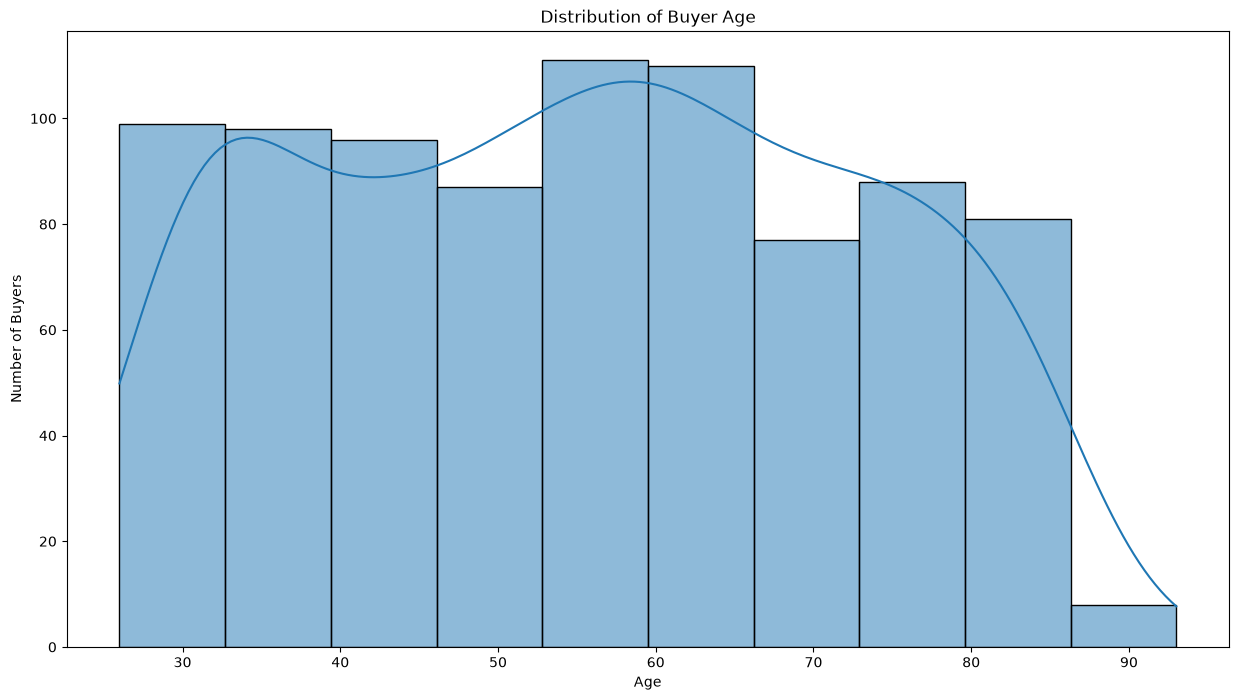

In [110]:
plt.figure(figsize=(15, 8))

sns.histplot(
    buyer_data["age"],
    bins=10,
    kde=True
)

plt.title("Distribution of Buyer Age")
plt.xlabel("Age")
plt.ylabel("Number of Buyers")

plt.show()

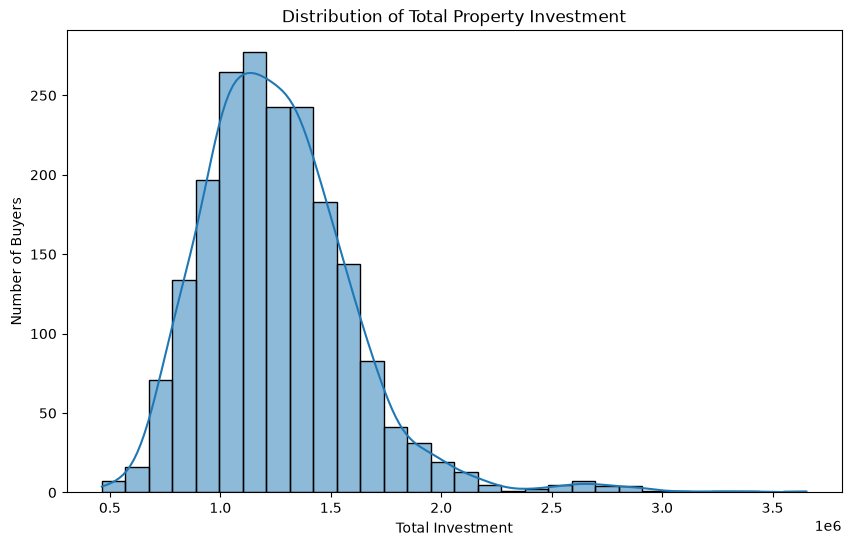

In [111]:
plt.figure(figsize=(10, 6))

sns.histplot(
    buyer_data["total_investment"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Property Investment")
plt.xlabel("Total Investment")
plt.ylabel("Number of Buyers")

plt.show()

In [112]:
buyer_data.shape

(2000, 18)

In [113]:
buyer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   client_id               2000 non-null   str           
 1   client_type             2000 non-null   str           
 2   first_name              2000 non-null   str           
 3   last_name               2000 non-null   str           
 4   date_of_birth           855 non-null    datetime64[us]
 5   gender                  2000 non-null   str           
 6   country                 2000 non-null   str           
 7   region                  2000 non-null   str           
 8   acquisition_purpose     2000 non-null   str           
 9   satisfaction_score      2000 non-null   int64         
 10  loan_applied            2000 non-null   str           
 11  referral_channel        2000 non-null   str           
 12  age                     855 non-null    Int64         
 13 

In [114]:
buyer_data[
    [
        "age",
        "satisfaction_score",
        "total_properties",
        "total_investment",
        "average_property_value",
        "average_property_size"
    ]
].describe()

,age,satisfaction_score,total_properties,total_investment,average_property_value,average_property_size
count,855.0,2000.000000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,55.540351,3.029000,3.6525,1.260375e+06,347089.955869,1147.479668
std,17.214461,1.413562,0.8397,3.478307e+05,69721.821814,219.922587
min,26.0,1.000000,3.0000,4.636120e+05,154537.316667,564.010000
25%,41.0,2.000000,3.0000,1.025238e+06,295807.677708,984.952500
50%,56.0,3.000000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,70.0,4.000000,4.0000,1.441974e+06,390843.316875,1296.562500
max,93.0,5.000000,13.0000,3.653385e+06,563423.500000,1800.450000


In [115]:
clustering_data = buyer_data[
    [
        "client_type",
        "gender",
        "region",
        "acquisition_purpose",
        "loan_applied",
        "satisfaction_score",
        "age",
        "total_properties",
        "total_investment",
        "average_property_value",
        "average_property_size"
    ]
].copy()

In [116]:
clustering_data.head()

,client_type,gender,region,acquisition_purpose,loan_applied,satisfaction_score,age,total_properties,total_investment,average_property_value,average_property_size
0,Individual,F,California,Home,Yes,4,58,4,1246764.72,311691.180000,983.885000
1,Individual,M,California,Home,No,1,<NA>,5,1841095.93,368219.186000,1187.942000
2,Individual,M,California,Home,Yes,4,67,5,1661457.59,332291.518000,1058.110000
3,Individual,M,California,Home,No,5,<NA>,6,1608263.51,268043.918333,937.103333
4,Company,M,California,Investment,No,5,<NA>,13,3653385.38,281029.644615,927.296154


In [117]:
from sklearn.preprocessing import OneHotEncoder

In [118]:
categorical_features = [
    "client_type",
    "gender",
    "region",
    "acquisition_purpose",
    "loan_applied"
]

numerical_features = [
    "satisfaction_score",
    "age",
    "total_properties",
    "total_investment",
    "average_property_value",
    "average_property_size"
]

In [119]:
encoded_data = pd.get_dummies(
    clustering_data,
    columns=categorical_features,
    drop_first=True
)

In [120]:
encoded_data.head()

,satisfaction_score,age,total_properties,total_investment,average_property_value,average_property_size,client_type_Individual,gender_M,region_Arizona,region_Baja California,...,region_Victoria,region_Virginia,region_Wales,region_Wallonia,region_Washington,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Investment,loan_applied_Yes
0,4,58,4,1246764.72,311691.180000,983.885000,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,<NA>,5,1841095.93,368219.186000,1187.942000,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4,67,5,1661457.59,332291.518000,1058.110000,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
3,5,<NA>,6,1608263.51,268043.918333,937.103333,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,<NA>,13,3653385.38,281029.644615,927.296154,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [121]:
from sklearn.preprocessing import StandardScaler

In [122]:
scaler = StandardScaler()

In [123]:
encoded_data[numerical_features] = scaler.fit_transform(
    encoded_data[numerical_features]
)

In [124]:
encoded_data[numerical_features].describe()

,satisfaction_score,age,total_properties,total_investment,average_property_value,average_property_size
count,2.000000e+03,8.550000e+02,2.000000e+03,2.000000e+03,2.000000e+03,2.000000e+03
mean,1.065814e-17,-1.495879e-16,1.847411e-16,-4.263256e-16,-2.433609e-16,8.402168e-16
std,1.000250e+00,1.000585e+00,1.000250e+00,1.000250e+00,1.000250e+00,1.000250e+00
min,-1.435740e+00,-1.717024e+00,-7.772575e-01,-2.291238e+00,-2.762418e+00,-2.653732e+00
25%,-7.281302e-01,-8.451535e-01,-7.772575e-01,-6.761804e-01,-7.357109e-01,-7.392047e-01
50%,-2.052068e-02,2.671697e-02,4.139417e-01,-1.135386e-01,-7.985971e-02,-8.324556e-02
75%,6.870889e-01,8.404627e-01,4.139417e-01,5.222191e-01,6.276988e-01,6.780573e-01
max,1.394698e+00,2.177331e+00,1.113473e+01,6.881534e+00,3.103586e+00,2.969834e+00


In [125]:
X = encoded_data.copy()

print("Before K-Means:")
print("encoded_data shape:", encoded_data.shape)
print("X shape:", X.shape)

Before K-Means:
encoded_data shape: (2000, 66)
X shape: (2000, 66)


In [130]:
print("Missing values:", X.isna().sum().sum())
print("Infinite values:", np.isinf(X).sum().sum())

Missing values: 1145
Infinite values: 0


In [131]:
missing = X.isna().sum()

print(missing[missing > 0])

age    1145
dtype: int64


In [132]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=X.columns,
    index=X.index
)

print("X_imputed shape:", X_imputed.shape)
print("Missing values:", X_imputed.isna().sum().sum())

X_imputed shape: (2000, 66)
Missing values: 0


In [133]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = final_kmeans.fit_predict(X_imputed)

print("Cluster labels:", len(clusters))

Cluster labels: 2000


In [134]:
buyer_data["cluster"] = clusters

print(buyer_data.shape)
print(buyer_data["cluster"].value_counts())

(2000, 19)
cluster
0    1083
1     867
2      50
Name: count, dtype: int64


In [136]:
cluster_profile = buyer_data.groupby("cluster")[numerical_features].mean()

cluster_profile

,satisfaction_score,age,total_properties,total_investment,average_property_value,average_property_size
cluster,,,,,,
0,2.959372,55.553812,3.536473,1.050597e+06,298059.897822,992.031839
1,3.087659,54.881748,3.585928,1.455737e+06,409162.260744,1344.332671
2,3.520000,68.05,7.320000,2.416603e+06,332747.246645,1101.048560


In [137]:
cluster_profile.round(2)

,satisfaction_score,age,total_properties,total_investment,average_property_value,average_property_size
cluster,,,,,,
0,2.96,55.55,3.54,1050597.35,298059.90,992.03
1,3.09,54.88,3.59,1455736.90,409162.26,1344.33
2,3.52,68.05,7.32,2416602.86,332747.25,1101.05


In [138]:
print(buyer_data.columns.tolist())

['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'client_ref', 'total_properties', 'total_investment', 'average_property_value', 'average_property_size', 'cluster']


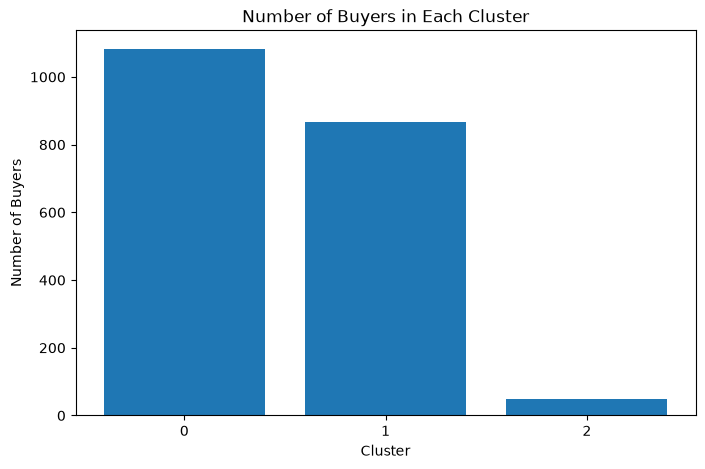

In [139]:
cluster_counts = buyer_data["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.title("Number of Buyers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")
plt.show()

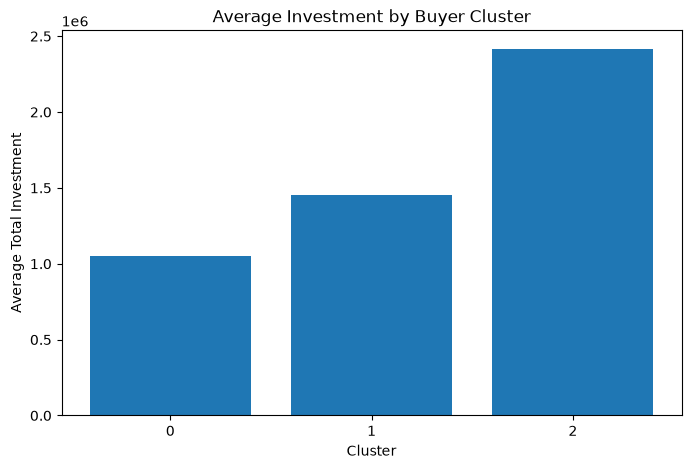

In [140]:
plt.figure(figsize=(8, 5))

plt.bar(
    cluster_profile.index.astype(str),
    cluster_profile["total_investment"]
)

plt.title("Average Investment by Buyer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Investment")
plt.show()

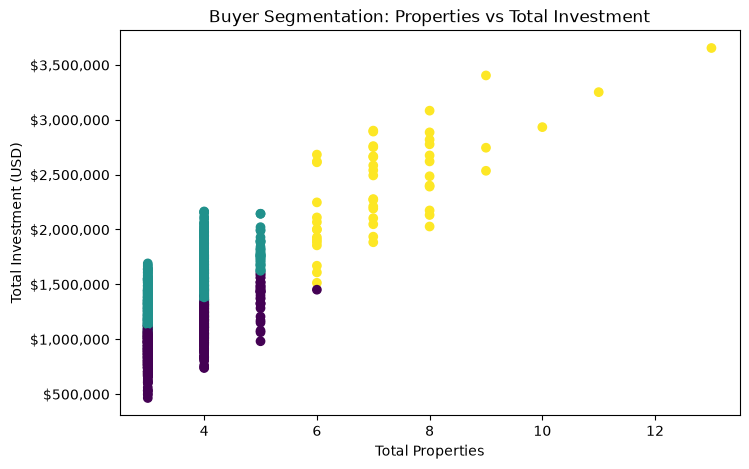

In [142]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8, 5))

plt.scatter(
    buyer_data["total_properties"],
    buyer_data["total_investment"],
    c=buyer_data["cluster"]
)

plt.title("Buyer Segmentation: Properties vs Total Investment")
plt.xlabel("Total Properties")
plt.ylabel("Total Investment (USD)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.show()

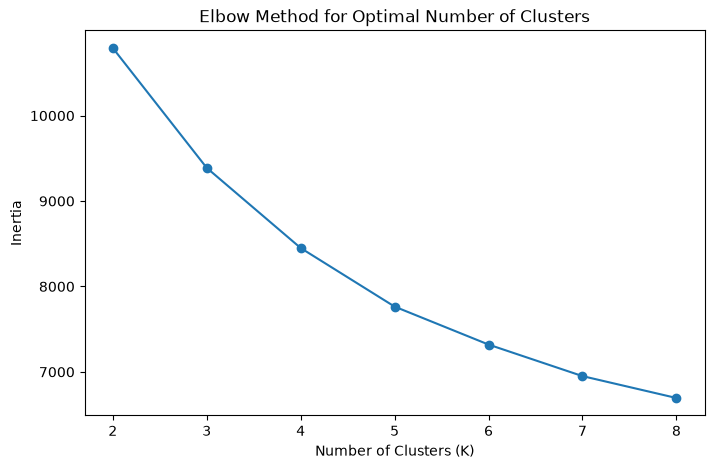

In [145]:
from sklearn.cluster import KMeans

inertia = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_imputed)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_values)

plt.show()

In [146]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_imputed)
    
    score = silhouette_score(X_imputed, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 9), silhouette_scores):
    print(f"K={k}: Silhouette Score = {score:.4f}")

K=2: Silhouette Score = 0.2093
K=3: Silhouette Score = 0.2178
K=4: Silhouette Score = 0.1631
K=5: Silhouette Score = 0.1437
K=6: Silhouette Score = 0.1301
K=7: Silhouette Score = 0.1283
K=8: Silhouette Score = 0.1287


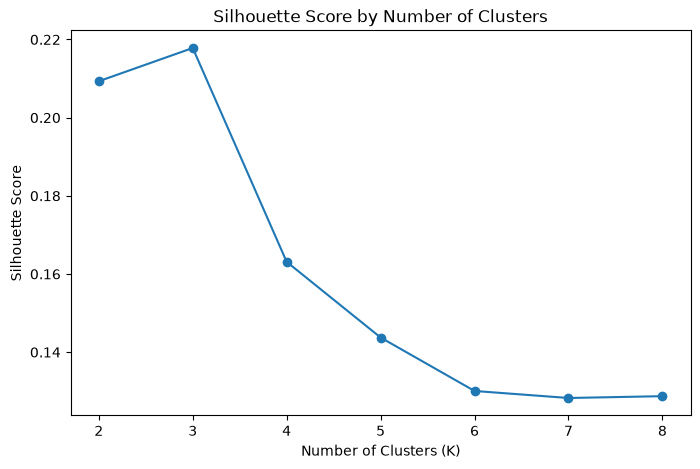

In [147]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 9))

plt.show()

In [148]:
cluster_profile = buyer_data.groupby("cluster")[numerical_features].mean()

In [149]:
cluster_size = (
    buyer_data["cluster"]
    .value_counts()
    .sort_index()
    .rename("buyer_count")
    .to_frame()
)

cluster_size["percentage"] = (
    cluster_size["buyer_count"] /
    len(buyer_data) * 100
).round(2)

cluster_size

,buyer_count,percentage
cluster,,
0,1083,54.15
1,867,43.35
2,50,2.50


In [150]:
categorical_features = [
    "client_type",
    "gender",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

for feature in categorical_features:
    print("\n" + "=" * 60)
    print(feature.upper())
    print("=" * 60)

    print(
        pd.crosstab(
            buyer_data["cluster"],
            buyer_data[feature],
            normalize="index"
        ).round(2) * 100
    )


CLIENT_TYPE
client_type  Company  Individual
cluster                         
0                5.0        95.0
1                6.0        94.0
2                4.0        96.0

GENDER
gender      F     M
cluster            
0        51.0  49.0
1        49.0  51.0
2        38.0  62.0

ACQUISITION_PURPOSE
acquisition_purpose  Home  Investment
cluster                              
0                    69.0        31.0
1                    70.0        30.0
2                    66.0        34.0

LOAN_APPLIED
loan_applied    No   Yes
cluster                 
0             63.0  37.0
1             64.0  36.0
2             68.0  32.0

REFERRAL_CHANNEL
referral_channel  Agency  Client  Website
cluster                                  
0                   36.0    10.0     54.0
1                   35.0     9.0     55.0
2                   26.0     4.0     70.0


In [151]:
for feature in ["country", "region"]:
    print("\n" + "=" * 60)
    print(feature.upper())
    print("=" * 60)

    result = pd.crosstab(
        buyer_data["cluster"],
        buyer_data[feature],
        normalize="index"
    ).round(3) * 100

    print(result)


COUNTRY
country  Australia  Belgium  Canada  Denmark  France  Germany  Mexico  Russia  \
cluster                                                                         
0              2.2      2.2     4.4      0.5     2.9      3.0     2.4     1.9   
1              1.7      2.1     4.2      1.2     2.4      2.7     1.6     1.7   
2              0.0      2.0     2.0      0.0     2.0      2.0     0.0     0.0   

country   UK   USA  
cluster             
0        4.7  75.8  
1        4.7  77.7  
2        6.0  86.0  

REGION
region   Alberta  Arizona  Baja California  Bavaria  Berlin  British Columbia  \
cluster                                                                         
0            1.7      5.7              0.4      0.5     0.6               0.8   
1            1.0      5.2              0.3      0.8     0.5               1.3   
2            0.0      2.0              0.0      0.0     0.0               0.0   

region   Brittany  Brussels  California  Capital Region  ...  Texa

In [152]:
country_profile = (
    buyer_data.groupby("cluster")["country"]
    .agg(lambda x: x.value_counts().index[0])
)

country_profile

cluster
0    USA
1    USA
2    USA
Name: country, dtype: str

In [153]:
region_profile = (
    buyer_data.groupby("cluster")["region"]
    .agg(lambda x: x.value_counts().index[0])
)

region_profile

cluster
0    California
1    California
2    California
Name: region, dtype: str

In [154]:
final_profile = buyer_data.groupby("cluster").agg(
    buyer_count=("client_id", "count"),
    avg_age=("age", "mean"),
    avg_properties=("total_properties", "mean"),
    avg_investment=("total_investment", "mean"),
    avg_property_value=("average_property_value", "mean"),
    avg_property_size=("average_property_size", "mean"),
    avg_satisfaction=("satisfaction_score", "mean")
).round(2)

final_profile["percentage"] = (
    final_profile["buyer_count"] /
    len(buyer_data) * 100
).round(2)

final_profile

,buyer_count,avg_age,avg_properties,avg_investment,avg_property_value,avg_property_size,avg_satisfaction,percentage
cluster,,,,,,,,
0,1083,55.55,3.54,1050597.35,298059.90,992.03,2.96,54.15
1,867,54.88,3.59,1455736.90,409162.26,1344.33,3.09,43.35
2,50,68.05,7.32,2416602.86,332747.25,1101.05,3.52,2.50


In [155]:
business_summary = final_profile[
    [
        "buyer_count",
        "percentage",
        "avg_investment",
        "avg_property_value",
        "avg_properties",
        "avg_satisfaction"
    ]
]

business_summary

,buyer_count,percentage,avg_investment,avg_property_value,avg_properties,avg_satisfaction
cluster,,,,,,
0,1083,54.15,1050597.35,298059.90,3.54,2.96
1,867,43.35,1455736.90,409162.26,3.59,3.09
2,50,2.50,2416602.86,332747.25,7.32,3.52


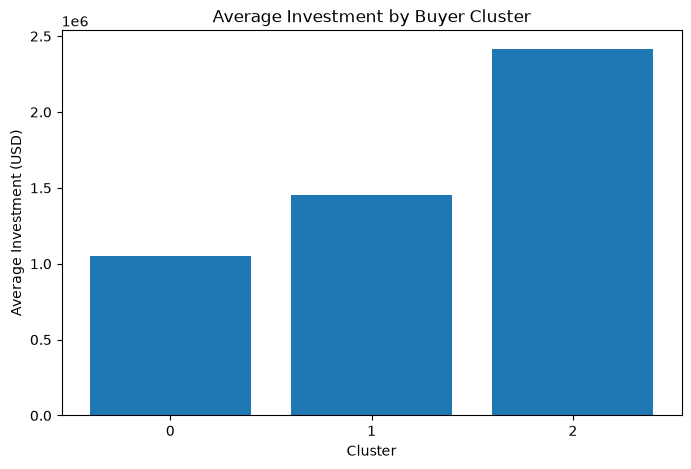

In [156]:
plt.figure(figsize=(8, 5))

plt.bar(
    business_summary.index.astype(str),
    business_summary["avg_investment"]
)

plt.title("Average Investment by Buyer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Investment (USD)")

plt.show()

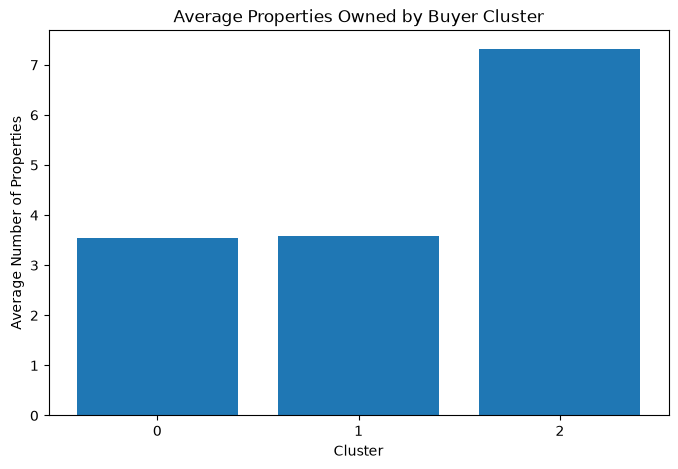

In [157]:
plt.figure(figsize=(8, 5))

plt.bar(
    business_summary.index.astype(str),
    business_summary["avg_properties"]
)

plt.title("Average Properties Owned by Buyer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Number of Properties")

plt.show()

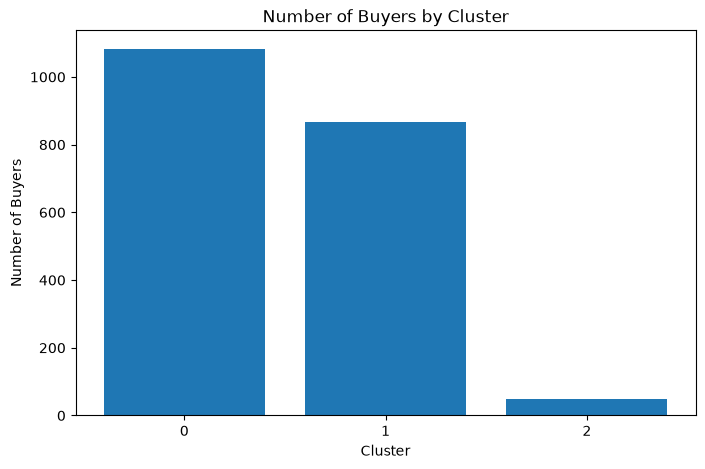

In [158]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_profile.index.astype(str),
    final_profile["buyer_count"]
)

plt.title("Number of Buyers by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Buyers")

plt.show()

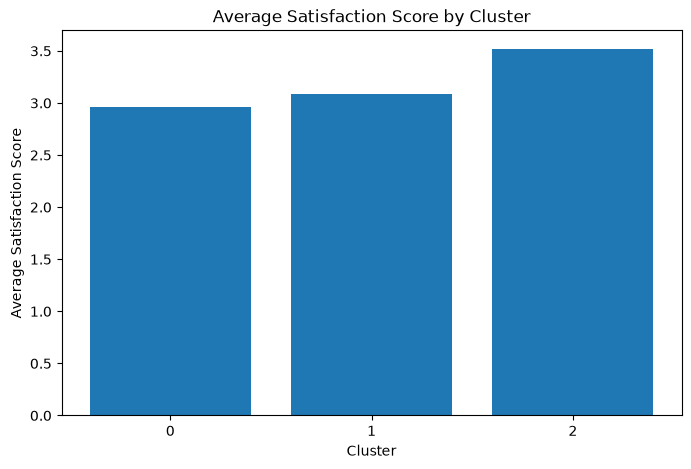

In [159]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_profile.index.astype(str),
    final_profile["avg_satisfaction"]
)

plt.title("Average Satisfaction Score by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Satisfaction Score")

plt.show()

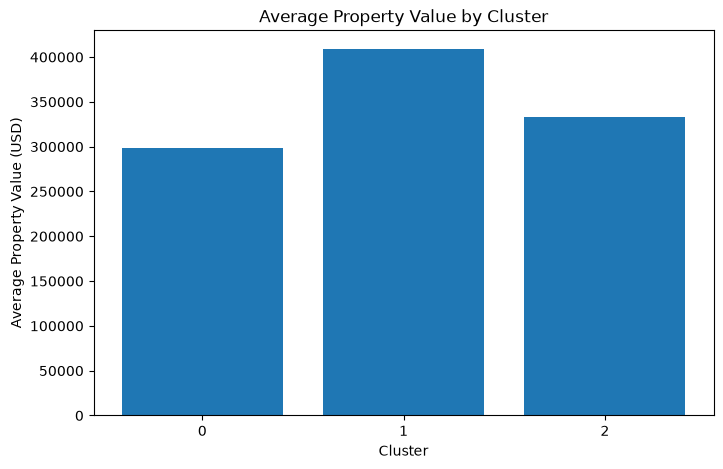

In [160]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_profile.index.astype(str),
    final_profile["avg_property_value"]
)

plt.title("Average Property Value by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Property Value (USD)")

plt.show()

## Business Insights and Recommendations

### Cluster 0 – Large, Lower-Investment Segment

- Represents 54.15% of the buyers.
- Average total investment is approximately $1.05M.
- Buyers own an average of 3.54 properties.
- Average satisfaction score is 2.96.
- Website and agency channels are the main acquisition sources.

### Cluster 1 – Higher-Property-Value Segment

- Represents 43.35% of the buyers.
- Average total investment is approximately $1.46M.
- Average property value is approximately $409K.
- Average property size is approximately 1,344.
- This cluster has the highest average property value among the three segments.

### Cluster 2 – Small, High-Investment Segment

- Represents 2.50% of the buyers.
- Average total investment is approximately $2.42M.
- Buyers own an average of 7.32 properties.
- Average satisfaction score is 3.52.
- 70% of buyers were acquired through the website.
- 86% of buyers are from the USA, and California is the most common region.

### Recommendations

1. Develop differentiated marketing strategies for each buyer segment.
2. Use digital/website channels to engage high-investment buyers, given the strong website representation in Cluster 2.
3. Promote higher-value and larger properties to Cluster 1 based on its average property value and size.
4. Analyze satisfaction drivers in Cluster 0 because it has the lowest average satisfaction score.
5. Monitor Cluster 2 separately because it represents a small proportion of buyers but has substantially higher average investment and property ownership.

In [165]:
buyer_data.to_csv("buyer_segmentation_results.csv", index=False)
final_profile.to_csv("cluster_profile.csv")

In [2]:
import pandas as pd

buyer_data = pd.read_csv("../data/buyer_segmentation_results.csv")

print("buyer_data shape:", buyer_data.shape)
print(buyer_data.columns.tolist())

buyer_data shape: (2000, 19)
['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'client_ref', 'total_properties', 'total_investment', 'average_property_value', 'average_property_size', 'cluster']


In [3]:
app_data = buyer_data[
    [
        "cluster",
        "age",
        "total_properties",
        "total_investment",
        "average_property_value",
        "average_property_size",
        "satisfaction_score"
    ]
].copy()

print("App dataset shape:", app_data.shape)

App dataset shape: (2000, 7)


In [4]:
app_data.to_csv(
    "../data/app_buyer_data.csv",
    index=False
)

print("App dataset saved successfully!")

App dataset saved successfully!
